# Beyond BLAST: generalized window functions

This notebook starts from the derivation in [equations.tex](sheet/equations.tex) and rewrites the window function in its most general form before specializing to the BLAST/N5K cases.

## Generalized window function

The generalized window function is
$$W_l^A(k,\chi)=f^A(\chi)j_l\!\left(k\,r(\chi)\right)$$

where $f^A(\chi)$ collects the tracer-specific weights and $r(\chi)$ is the radial distance associated with the background geometry. In a flat background, $r(\chi)=\chi$, so the expression reduces to the form used in BLAST.

The point of writing the window this way is that all observable-specific physics is isolated in $f^A(\chi)$, while the spherical Bessel factor keeps the full 3D radial dependence.

### Example: galaxy density

For a galaxy density tracer, the weight is
$$f^{\rm den}(\chi)=\frac{H(z)}{c}b(z)n(z)D(z)$$

so the corresponding generalized window is
$$W_l^{\rm den}(k,\chi)=\frac{H(z)}{c}b(z)n(z)D(z)\,j_l\!\left(k\,r(\chi)\right)$$

This is the basic object that later feeds the Hankel transform and, ultimately, the angular power spectrum integral.

## Hankel transform of the window

To move from a line-of-sight window to a spherical representation, we project the generalized window onto a second spherical Bessel basis. The natural object is the Hankel transform
$$\widetilde{W}_l^{A}(k,k') \equiv \int_0^{\infty} d\chi\, \chi^2\, W_l^{A}(k,\chi)\, j_l(k'\chi)$$

Using the generalized form $W_l^{A}(k,\chi)=f^A(\chi)j_l\!\left(k\,r(\chi)\right)$, this becomes
$$\widetilde{W}_l^{A}(k,k') = \int_0^{\infty} d\chi\, \chi^2\, f^A(\chi)\, j_l\!\left(k\,r(\chi)\right) j_l(k'\chi)$$

In a flat background, where $r(\chi)=\chi$, the transform simplifies to
$$\widetilde{W}_l^{A}(k,k') = \int_0^{\infty} d\chi\, \chi^2\, f^A(\chi)\, j_l(k\chi) j_l(k'\chi)$$

This is the spherical analogue of the standard BLAST window: the original tracer weight is now embedded inside a radial kernel that couples two wavenumbers.

## Spherical BLAST kernel

Once the two window functions have been Hankel transformed, the spherical correlation function is obtained by integrating over the internal wavenumber,
$$S_l^{AB}(k_1,k_2) = N_l^{AB} \int dk\, k^2\, P^{AB}(k,\chi,\chi')\, \widetilde{W}_l^{A}(k,k_1)\, \widetilde{W}_l^{B}(k,k_2)$$

If the matter power spectrum is written in separable growth form,
$$P^{AB}(k,\chi,\chi') = D(\chi)D(\chi')P_{\rm lin}^{AB}(k)$$

then the growth factors are absorbed into $f^A(\chi)$ and $f^B(\chi')$, and the spherical kernel becomes
$$S_l^{AB}(k_1,k_2) = N_l^{AB} \int dk\, k^2\, P_{\rm lin}^{AB}(k)\, \widetilde{W}_l^{A}(k,k_1)\, \widetilde{W}_l^{B}(k,k_2)$$

For galaxy clustering, the tracer weight is
$$f^{\rm den}(\chi)=\frac{H(z)}{c}b(z)n(z)D(z)$$

so the corresponding spherical kernel is controlled by the double-Bessel integral
$$\widetilde{W}_l^{\rm den}(k,k') = \int_0^{\infty} d\chi\, \chi^2\, \frac{H(z)}{c}b(z)n(z)D(z)\, j_l(k\chi)j_l(k'\chi)$$

This is the object that can be tabulated once and then reused for the different observable combinations in the same way as in the BLAST notebook.

$$\tilde{T}_{n ; \ell}^{\mathrm{AB}}\left(\chi_1, \chi_2\right) \equiv \int_{k_{\min }}^{k_{\max }} \mathrm{d} k f^{\mathrm{AB}}(k) T_n(k) j_{\ell}\left(k \chi_1\right) j_{\ell}\left(k\chi_2\right) j_{\ell}\left(k'\chi_1\right) j_{\ell}\left(k''\chi_2\right)$$

In [1]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")

  Activating project at `~/Desktop/cosmo/blast_code`
  No Changes to `~/Desktop/cosmo/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/blast_code/Manifest.toml`


Main.blast_tutorials

In [2]:
include("blast_code/src/new_funcs.jl")

compute_T̃_beyond (generic function with 1 method)

In [3]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using LoopVectorization
using LinearAlgebra
using Revise
using SpecialFunctions
using .Blast
using .blast_tutorials

In [4]:
ℓ = Blast.ℓ
n_chi = 20
x_min = 26
x_max = 7000
χ = LinRange(x_min, x_max, n_chi)
R = chebpoints(n_chi, -1, 1)
R = reverse(R[R.>0])
nR = length(R)
kmax = 200/13
kmin = 2.5/x_max
n_cheb = 19
β = 2 #0 per CL, 2 per CC, -2 per LL
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax))
k1 = kmin
k2 = kmax
N = 2^(15)+1

32769

In [5]:
#to save plot and parameters for each run

using Dates

# Create timestamped folder for outputs
timestamp = Dates.format(now(), "yyyymmdd_HHMMSS")
output_dir = "run_$(timestamp)"
mkpath(output_dir)
println("Output directory: $output_dir")

# Helper function to save plots
function save_plot(p, name::String)
    filepath = joinpath(output_dir, "$(name).png")
    savefig(p, filepath)
    println("Saved: $filepath")
    return p
end

# Save parameters to file
params_dict = Dict(
    "ℓ" => ℓ,
    "n_chi" => n_chi,
    "x_min" => x_min,
    "x_max" => x_max,
    "nR" => nR,
    "kmax" => kmax,
    "kmin" => kmin,
    "n_cheb" => n_cheb,
    "β" => β,
    "k1" => k1,
    "k2" => k2,
    "N" => N,
    "timestamp" => timestamp
)

# Save as JSON
using JSON
open(joinpath(output_dir, "parameters.json"), "w") do f
    JSON.print(f, params_dict, 2)
end
println("Parameters saved to: $(joinpath(output_dir, "parameters.json"))")

# Also save as readable text file
open(joinpath(output_dir, "parameters.txt"), "w") do f
    write(f, "Beyond BLAST Run Parameters\n")
    write(f, "==========================\n")
    write(f, "Timestamp: $timestamp\n\n")
    write(f, "ℓ array length: $(length(ℓ))\n")
    write(f, "n_chi: $n_chi\n")
    write(f, "x_min: $x_min\n")
    write(f, "x_max: $x_max\n")
    write(f, "nR: $nR\n")
    write(f, "kmax: $kmax\n")
    write(f, "kmin: $kmin\n")
    write(f, "n_cheb: $n_cheb\n")
    write(f, "β: $β\n")
    write(f, "k1: $k1\n")
    write(f, "k2: $k2\n")
    write(f, "N: $N\n")
end
println("Parameters also saved to: $(joinpath(output_dir, "parameters.txt"))")

Output directory: run_20260513_213424
Parameters saved to: run_20260513_213424/parameters.json
Parameters also saved to: run_20260513_213424/parameters.txt


In [6]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy")
χ_b = npzread("blast_code/data/background/chi.npy")
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b);

In [7]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

In [8]:
#Interpolating the power spectrum
#Linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))

InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x, y))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

## Practical decomposition recipe

To decompose $S_l^{AB}$ in the BLAST style, sample the power spectrum on the Chebyshev $k$ grid first. In this notebook, `Pvals` means the array of sampled values
$$P_{\rm vals}[n,j,i] = P^{AB}\!\left(k_n,\chi_j,\chi_j R_i\right)$$

with shape $(n_k,n_\chi,n_R)$. Once that array is built, the rest is the same BLAST pattern: FFT/DCT along the $k$ axis, precompute the spherical Bessel integrals, then contract the two tensors.

### Updated precomputation of $\tilde T_\ell$
The extra spherical-Bessel factors that depend on the external wavenumbers can be pulled outside the $k$-integral, so the reusable BLAST piece is still the two-Bessel object computed by `compute_T̃`.
For a fixed pair $(k_1,k_2)$, the generalized kernel is therefore the old tensor dressed by
$$j_\ell(k_1\chi)\,j_\ell(k_2\chi')$$
so the precomputation step stays the same in structure, but the final contraction uses the dressed tensor.

In [9]:
#T_LL_full[i,:,:,:,:,:], T_CL_full[i,:,:,:,:,:], T_CC_full[i,:,:,:,:,:] =
#    compute_T̃_beyond(ℓ[i], χ, R, kp, kpp, kmin, kmax; n_cheb, N)

In [10]:
# Define k' and k'' on Chebyshev grid
kp = kpp = 10 .^ chebpoints(n_cheb, log10(kmin), log10(kmax))

# Compute T̃ for each ℓ value with new function and time it
computation_time = @elapsed begin
    T_LL_full = zeros(length(ℓ), length(χ), length(R), length(kp), length(kpp), n_cheb + 1)
    T_CL_full = zeros(length(ℓ), length(χ), length(R), length(kp), length(kpp), n_cheb + 1)
    T_CC_full = zeros(length(ℓ), length(χ), length(R), length(kp), length(kpp), n_cheb + 1)

    for i in eachindex(ℓ)
        T_LL_full[i,:,:,:,:,:], T_CL_full[i,:,:,:,:,:], T_CC_full[i,:,:,:,:,:] = compute_T̃_beyond(ℓ[i], χ, R, kp, kpp, kmin, kmax; n_cheb, N)
        println("step ", i, " completed")
    end

    # Sum over k' and k'' dimensions (dims 4 and 5)
    global T_LL = dropdims(sum(T_LL_full, dims=(4,5)), dims=(4,5))
    global T_CL = dropdims(sum(T_CL_full, dims=(4,5)), dims=(4,5))
    global T_CC = dropdims(sum(T_CC_full, dims=(4,5)), dims=(4,5))
end

# Append computation time to parameters file
open(joinpath(output_dir, "parameters.txt"), "a") do f
    write(f, "\nComputation Time:\n")
    write(f, "================\n")
    write(f, "T̃ computation time: $(computation_time) seconds ($(computation_time/60) minutes)\n")
end
println("Computation took: $(computation_time) seconds")

step 1 completed
step 2 completed
step 3 completed
step 4 completed
step 5 completed
step 6 completed
step 7 completed
step 8 completed
step 9 completed
step 10 completed
step 11 completed
step 12 completed
step 13 completed
step 14 completed
step 15 completed
step 16 completed
step 17 completed
step 18 completed
step 19 completed
step 20 completed
step 21 completed
step 22 completed
Computation took: 5726.034747417 seconds


In [11]:
# Now shapes are back to (length(ℓ), n_chi, nR, n_cheb+1)
print("Shape of the computed T̃_LL: ", size(T_LL), "\n")
print("Shape of the computed T̃_CL: ", size(T_CL), "\n")
print("Shape of the computed T̃_CC: ", size(T_CC), "\n")

Shape of the computed T̃_LL: (22, 20, 10, 20)
Shape of the computed T̃_CL: (22, 20, 10, 20)
Shape of the computed T̃_CC: (22, 20, 10, 20)


In [12]:
cosmo = Blast.FlatΛCDM()
z_range = z_of_χ.(χ)
bgrid = Blast.CosmologicalGrid(z_range = z_range)
bg = Blast.BackgroundQuantities(Hz_array = zeros(length(z_range)), χz_array = Array(χ));

In [13]:
cheb_coeff = zeros(n_chi, nR, n_cheb + 1)
vals = power_spectrum.(10 .^ k_cheb, χ[1], χ[1] * R[1])
plan = Blast.plan_fft(vals)

for i in 1:nR
    for j in 1:n_chi
        vals = power_spectrum.(10 .^ k_cheb, χ[j], χ[j] * R[i])
        cheb_coeff[j, i, :] = Blast.fast_chebcoefs(vals, plan)
    end
end
println("size of the chebyshev coefficients term")
println(size(cheb_coeff))
println("size of the computed T̃ term")
println(size(T_LL))

size of the chebyshev coefficients term
(20, 10, 20)
size of the computed T̃ term
(22, 20, 10, 20)


In [14]:
# Continue as before with w_ell_tullio
w_LL = Blast.w_ell_tullio(cheb_coeff, T_LL)
w_CL = Blast.w_ell_tullio(cheb_coeff, T_CL)
w_CC = Blast.w_ell_tullio(cheb_coeff, T_CC);

Saved: run_20260513_213424/wLL_ell2.png


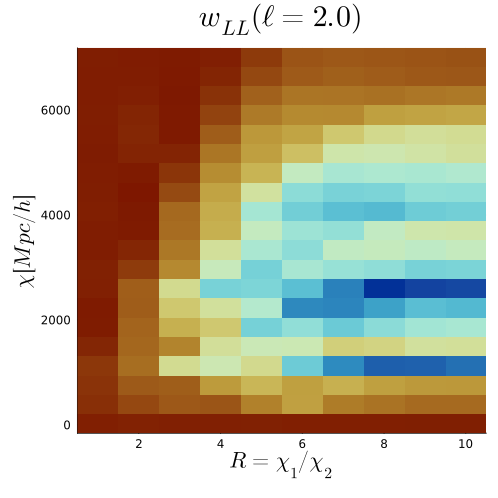

In [15]:
p1 = heatmap(1:nR, χ, w_LL[1,:,:]./maximum(w_LL[1,:,:]), size = (500,500), title=L"w_{LL}(ℓ=2.0)", 
    c =:roma , xlabel=L"R=\chi_1/\chi_2",ylabel=L"\chi[Mpc/h]", legend=:none,
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)
save_plot(p1, "wLL_ell2")

# plot!([16,16],[26, 7200],arrow=true,color=:black,linewidth=3,label=nothing, size = (500,500)) 
# annotate!(11, 7300, text(L"R=0.5",14), :black)

# plot!([28,28],[26, 7200],arrow=true,color=:black,linewidth=3,label=nothing, size = (500,500)) 
# annotate!(23, 7300, text(L"R=0.8",14), :black)

# plot!([34,34],[26, 7200],arrow=true,color=:black,linewidth=3,label=nothing,axis=([], false), size = (500,500)) 
# annotate!(34, 7400, text(L"R=0.9",14), :black)

Saved: run_20260513_213424/wLL_ell211.png


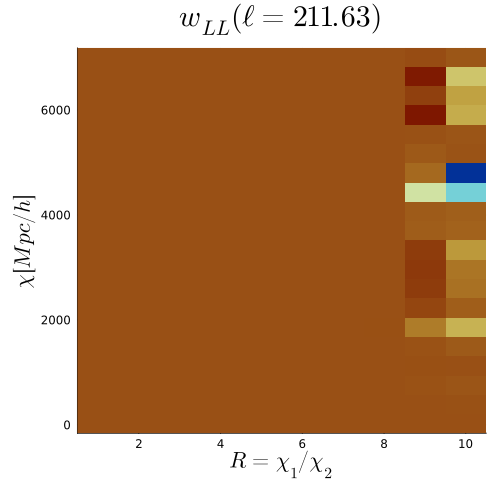

In [16]:
p2 = heatmap(1:nR, χ, w_LL[22,:,:]./maximum(w_LL[22,:,:]), size = (500,500), title=L"w_{LL}(ℓ=211.63)",
    legend = :none, c =:roma , xlabel=L"R=\chi_1/\chi_2",ylabel=L"\chi[Mpc/h]",
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)
save_plot(p2, "wLL_ell211")

# plot!([16,16],[26, 7200],arrow=true,color=:black,linewidth=3,label="R=0.5", size = (500,500)) 
# annotate!(11, 7300, text(L"R=0.5",14), :black)

# plot!([28,28],[26, 7200],arrow=true,color=:black,linewidth=3,label="R=0.5", size = (500,500)) 
# annotate!(23, 7300, text(L"R=0.8",14), :black)

# plot!([34,34],[26, 7200],arrow=true,color=:black,linewidth=3,label="R=0.5",axis=([], false), size = (500,500)) 
# annotate!(34, 7400, text(L"R=0.9",14), :black)

In [17]:
# Load N5K n(z), needed to compute lensing and clustering kernels
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")

Dict{String, Array{Float64}} with 4 entries:
  "dNdz_cl" => [9.51877e-8 1.11093e-13 … 5.97529e-61 6.25179e-67; 1.246e-7 1.56…
  "z_sh"    => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.014…
  "dNdz_sh" => [0.106801 1.52148e-9 … 6.04656e-24 7.57113e-34; 0.111443 1.76706…
  "z_cl"    => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.014…

In [18]:
GalKernels = Blast.GalaxyKernel(10, length(bgrid.z_range))
Blast.compute_kernel!(n5k_bins["dNdz_cl"]',  n5k_bins["z_cl"], GalKernels, bgrid, bg, cosmo)

In [19]:
ShearKernels = Blast.ShearKernel(4, length(bgrid.z_range))
Blast.compute_kernel!(n5k_bins["dNdz_sh"]', n5k_bins["z_sh"], ShearKernels, bgrid, bg, cosmo)

In [20]:
#Loading the N5K pre-computed kernel to check that they match!
W = npzread("blast_code/data/kernels_fullwidth.npz")

Dict{String, Array{Float64}} with 6 entries:
  "chi_cl"     => [25.9606, 33.7127, 41.4584, 49.1976, 56.9303, 64.6566, 72.376…
  "kernels_sh" => [6.04145e-7 7.78856e-7 … 0.0 0.0; 6.14932e-7 7.9704e-7 … 0.0 …
  "z_sh"       => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.…
  "chi_sh"     => [25.9606, 33.7127, 41.4584, 49.1976, 56.9303, 64.6566, 72.376…
  "kernels_cl" => [0.0 1.02182e-10 … 0.0 0.0; 0.0 9.54391e-17 … 0.0 0.0; … ; 0.…
  "z_cl"       => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.…

Saved: run_20260513_213424/clustering_kernels.png


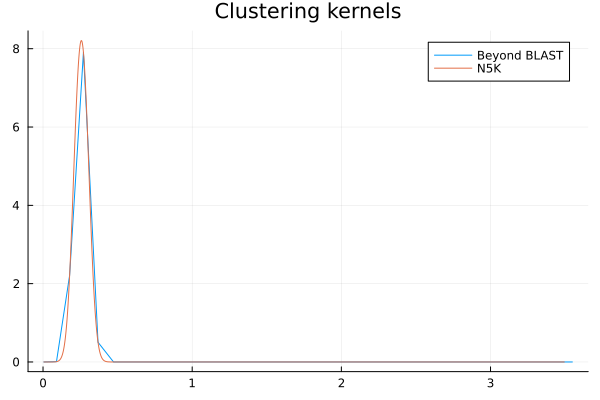

In [21]:
i_bin = 1

interp = DataInterpolations.AkimaInterpolation( W["kernels_cl"][i_bin,:], W["z_cl"], extrapolation = ExtrapolationType.Linear)
intn, _ = quadgk(x -> interp.(x), 0., 3.5)

interp = DataInterpolations.AkimaInterpolation( GalKernels.Kernel[i_bin,:], bgrid.z_range, extrapolation = ExtrapolationType.Linear)
intb, _ = quadgk(x -> interp.(x), 0., 3.5)

p3 = plot(bgrid.z_range, GalKernels.Kernel[i_bin,:]/intb, label="Beyond BLAST", title = "Clustering kernels")
plot!(p3, W["z_cl"], W["kernels_cl"][i_bin,:]/intn, label="N5K")
save_plot(p3, "clustering_kernels")

Saved: run_20260513_213424/shear_kernels.png


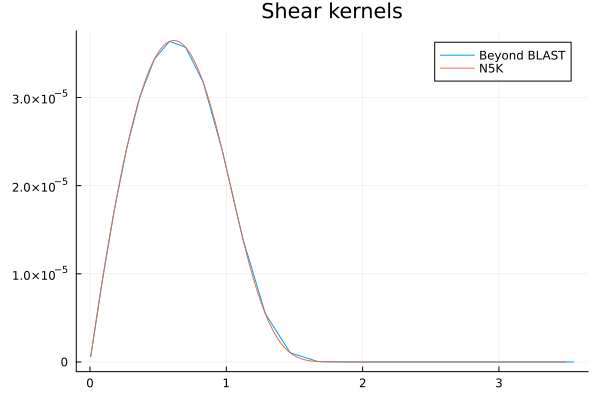

In [22]:
bin = 4

p4 = plot(bgrid.z_range, ShearKernels.Kernel[bin,:], label="Beyond BLAST", title = "Shear kernels")
plot!(p4, W["z_sh"], W["kernels_sh"][bin,:], label="N5K")
save_plot(p4, "shear_kernels")

In [23]:
K_CC, K_CL, K_LL = blast_tutorials.compute_kernels(W, χ, R)
w_χ = Blast.simpson_weight_array(n_chi)
w_R = Blast.get_clencurt_weights_R_integration(2*nR+1)
pref_CC = Blast.get_ell_prefactor(GalKernels, GalKernels, ℓ)
pref_CL = Blast.get_ell_prefactor(ShearKernels, GalKernels, ℓ)
pref_LL = Blast.get_ell_prefactor(ShearKernels, ShearKernels, ℓ);

In [24]:
clustering_Cℓ = Blast.compute_Cℓ(w_CC, K_CC, bg, w_χ, w_R, pref_CC)
shear_Cℓ = Blast.compute_Cℓ(w_LL, K_LL, bg, w_χ, w_R, pref_LL)
cross_Cℓ = Blast.compute_Cℓ(w_CL, K_CL, bg, w_χ, w_R, pref_CL);

In [25]:
@benchmark Blast.compute_Cℓ(w_CC, K_CC, bg, w_χ, w_R, pref_CC)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  68.542 μs … 534.584 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     68.917 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   69.688 μs ±   5.294 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▇█▄▅▆▅▂▁▂▁ ▂▂▁▁▁                                             ▂
  ███████████████████▇▇▆▇▆▆▆▅▅▅▅▄▄▃▁▃▄▅▃▄▄▃▄▅▄▄▃▅▅▄▄▄▄▆▄▆▄▄▆▅▆ █
  68.5 μs       Histogram: log(frequency) by time      83.4 μs <

 Memory estimate: 17.38 KiB, allocs estimate: 4.

In [26]:
dtype = Float64
Cℓ_CC_limb = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber_linear_full.npy"))
Cℓ_CL_limb =  dtype.(npzread("blast_code/data/Limber/Cl_CL_limber_linear_full.npy"))
Cℓ_LL_limb =  dtype.(npzread("blast_code/data/Limber/Cl_LL_limber_linear_full.npy"))
Cℓ_CC_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber_nl_full.npy"))
Cℓ_CL_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_CL_limber_nl_full.npy"))
Cℓ_LL_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_LL_limber_nl_full.npy"));

In [27]:
final_clustering_Cℓ = clustering_Cℓ + Cℓ_CC_limb_nl - Cℓ_CC_limb
final_cross_Cℓ = cross_Cℓ + Cℓ_CL_limb_nl - Cℓ_CL_limb
final_shear_Cℓ = shear_Cℓ + Cℓ_LL_limb_nl - Cℓ_LL_limb;

In [28]:
### add Limber Cl's in chebyshev points for l>200
Cℓ_CC_limb = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber+200_full.npy"))
Cℓ_CL_limb = dtype.(npzread("blast_code/data/Limber/Cl_CL_limber+200_full.npy"))
Cℓ_LL_limb = dtype.(npzread("blast_code/data/Limber/Cl_LL_limber+200_full.npy"))
total_Cℓ_CC = cat(final_clustering_Cℓ, Cℓ_CC_limb, dims=1)
total_Cℓ_CL = cat(final_cross_Cℓ, Cℓ_CL_limb, dims=1)
total_Cℓ_LL = cat(final_shear_Cℓ, Cℓ_LL_limb, dims=1);

In [29]:
#N5K benchmarks
dtype = Float64

benchmark_gg = npzread("blast_code/data/benchmarks_nl_full_clgg.npz")
benchmark_ll = npzread("blast_code/data/benchmarks_nl_full_clss.npz")
benchmark_gl = npzread("blast_code/data/benchmarks_nl_full_clgs.npz")

#Extracting C_ℓ
gg = dtype.(benchmark_gg["cls"])
ll = dtype.(benchmark_ll["cls"])
gl = dtype.(benchmark_gl["cls"])
ell = dtype.(benchmark_gg["ls"])

#Reshaping them into the same Blast's format
gg_reshaped = zeros( dtype, length(ell), 10, 10)
counter = 1

for i in 1:10
    for j in i:10
        gg_reshaped[:,i,j] = gg[counter, :]
        gg_reshaped[:,j,i] = gg_reshaped[:,i,j]
        counter += 1
    end
end

ll_reshaped = zeros(dtype, length(ell), 5, 5)
counter = 1

for i in 1:5
    for j in i:5
        ll_reshaped[:,i,j] = ll[counter, :]
        ll_reshaped[:,j,i] = ll_reshaped[:,i,j]
        counter += 1
    end
end

gl_reshaped = zeros( dtype, length(ell), 10, 5)
counter = 1

for i in 1:10
    for j in 1:5
        gl_reshaped[:,i,j] = gl[counter, :]
        counter += 1
    end
end

In [30]:
# Interpolating to go on the same n5k grid
elle = dtype.(reverse(chebpoints(100, 2, 2000)))
ℓ_min = 2
ℓ_max = 2000

interp_Cℓ_CC = zeros(dtype, length(ell), 10, 10)  # ← ell → elle
interp_Cℓ_CL = zeros(dtype, length(ell), 10, 5)
interp_Cℓ_LL = zeros(dtype, length(ell), 5, 5)

for i in 1:10
    for j in i:10
        interpol = chebinterp(reverse(total_Cℓ_CC[:,i,j].*elle.*elle), ℓ_min, ℓ_max)
        interp_Cℓ_CC[:,i,j] = interpol.(ell) ./ (ell.*ell)  # ← ell → elle
        interp_Cℓ_CC[:,j,i] = interp_Cℓ_CC[:,i,j]
    end
end

for i in 1:10
    for j in 1:5
        interpol = chebinterp(reverse(total_Cℓ_CL[:,i,j].*elle.*elle), ℓ_min, ℓ_max)
        interp_Cℓ_CL[:,i,j] = interpol.(ell) ./ (ell.*ell)  # ← ell → elle
    end
end

for i in 1:5
    for j in i:5
        interpol = chebinterp(reverse(total_Cℓ_LL[:,i,j].*elle.*elle), ℓ_min, ℓ_max)
        interp_Cℓ_LL[:,i,j] = interpol.(ell) ./ (ell.*ell)  # ← ell → elle
        interp_Cℓ_LL[:,j,i] = interp_Cℓ_LL[:,i,j]
    end
end

Saved: run_20260513_213424/Cℓ_gg_linear_scale.png


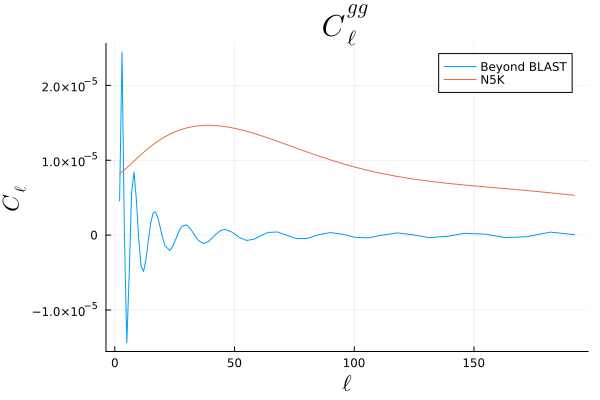

In [31]:
i = 10
j = 10
nl = 60 #set this to 103 to see up to ℓ=2000.
p5 = plot(ell[1:nl], interp_Cℓ_CC[1:nl,i,j], label="Beyond BLAST", title = L"$C_\ell^{gg}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$C_\ell$", labelfontsize=15)
plot!(p5, ell[1:nl], gg_reshaped[1:nl,i,j], label = "N5K")
save_plot(p5, "Cℓ_gg_linear_scale")

Saved: run_20260513_213424/Cℓ_gg_ell_scaling.png


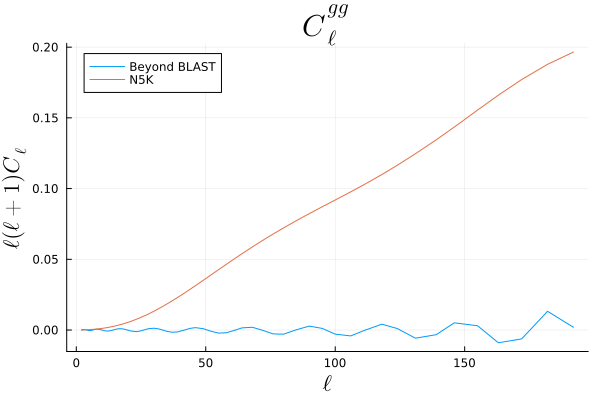

In [32]:
i = 10
j = 10
nl = 60 #set this to 103 to see up to ℓ=2000.
p6 = plot(ell[1:nl], interp_Cℓ_CC[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label="Beyond BLAST", title = L"$C_\ell^{gg}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$\ell(\ell+1)C_\ell$", labelfontsize=15)
plot!(p6, ell[1:nl], gg_reshaped[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label = "N5K")
save_plot(p6, "Cℓ_gg_ell_scaling")

Saved: run_20260513_213424/Cℓ_gs_linear_scale.png


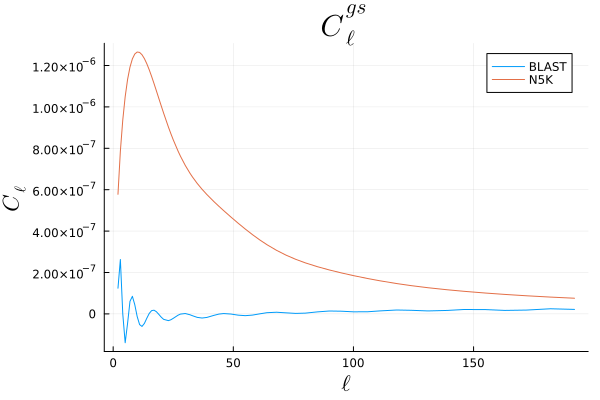

In [33]:
i = 1
j = 2
nl = 60 #set this to 103 to see up to ℓ=2000.
p7 = plot(ell[1:nl], interp_Cℓ_CL[1:nl,i,j], label="BLAST", title = L"$C_\ell^{gs}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$C_\ell$", labelfontsize=15)
plot!(ell[1:nl], gl_reshaped[1:nl,i,j], label = "N5K")
save_plot(p7, "Cℓ_gs_linear_scale")

Saved: run_20260513_213424/Cℓ_gs_ell_scaling.png


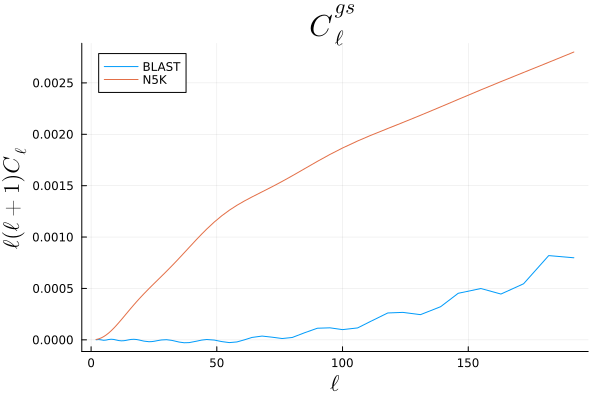

In [34]:
i = 1
j = 2
nl = 60 #set this to 103 to see up to ℓ=2000.
p8 = plot(ell[1:nl], interp_Cℓ_CL[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label="BLAST", title = L"$C_\ell^{gs}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$\ell(\ell+1)C_\ell$", labelfontsize=15)
plot!(ell[1:nl], gl_reshaped[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label = "N5K")
save_plot(p8, "Cℓ_gs_ell_scaling")

Saved: run_20260513_213424/Cℓ_ss_linear_scale.png


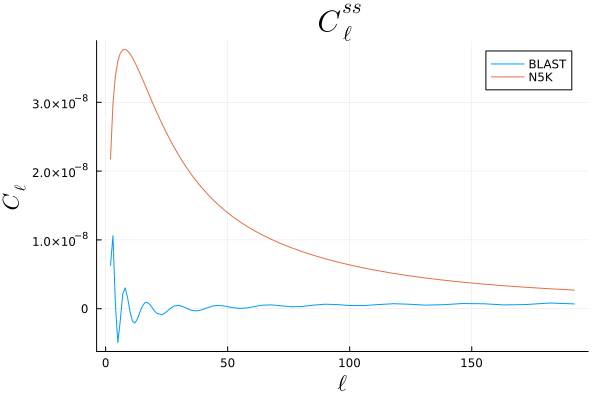

In [35]:
i = 3
j = 3
nl = 60 #set this to 103 to see up to ℓ=2000.
p9 = plot(ell[1:nl], interp_Cℓ_LL[1:nl,i,j], label="BLAST", title = L"$C_\ell^{ss}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$C_\ell$", labelfontsize=15)
plot!(ell[1:nl], ll_reshaped[1:nl,i,j], label = "N5K")
save_plot(p9, "Cℓ_ss_linear_scale")

Saved: run_20260513_213424/Cℓ_ss_ell_scaling.png


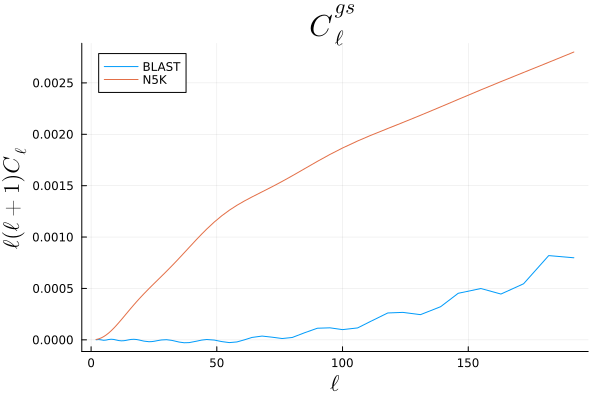

In [36]:
i = 3
j = 3
nl = 60 #set this to 103 to see up to ℓ=2000.
p10 = plot(ell[1:nl], interp_Cℓ_LL[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label="BLAST", title = L"$C_\ell^{aa}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$\ell(\ell+1)C_\ell$", labelfontsize=15)
plot!(ell[1:nl], ll_reshaped[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label = "N5K")
save_plot(p8, "Cℓ_ss_ell_scaling")